# Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Загрузка и первичных данных с сбросом лишних столбцов

In [2]:
df = pd.read_csv('bank.csv')

print(f"Размер датасета: {df.shape} клиентов и {df.shape[1]} признаков")
print(df.columns)
df.info()
df = df.drop(['poutcome', 'contact'], axis=1)

# Убрали данные столбцы, потому что они не несут полезной цифровой информации
# poutcome - большинство клиентов имеют неизвестный прошлый доход
# contact - просто указывает какой телефон имеет клиент

economic_stats = df.groupby('education')[['balance', 'age']].mean()
print('\nСредний баланс по уровню образования\n', economic_stats)

df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

print('\nПервые 3 строки данных')
df.head(3)

Размер датасета: (11162, 17) клиентов и 17 признаков
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,deposit
0,59,admin.,married,secondary,no,2343,yes,no,5,may,1042,1,-1,0,1
1,56,admin.,married,secondary,no,45,no,no,5,may,1467,1,-1,0,1
2,41,technician,married,secondary,no,1270,yes,no,5,may,1389,1,-1,0,1


# Визуализация данных через график "усатой коробки"

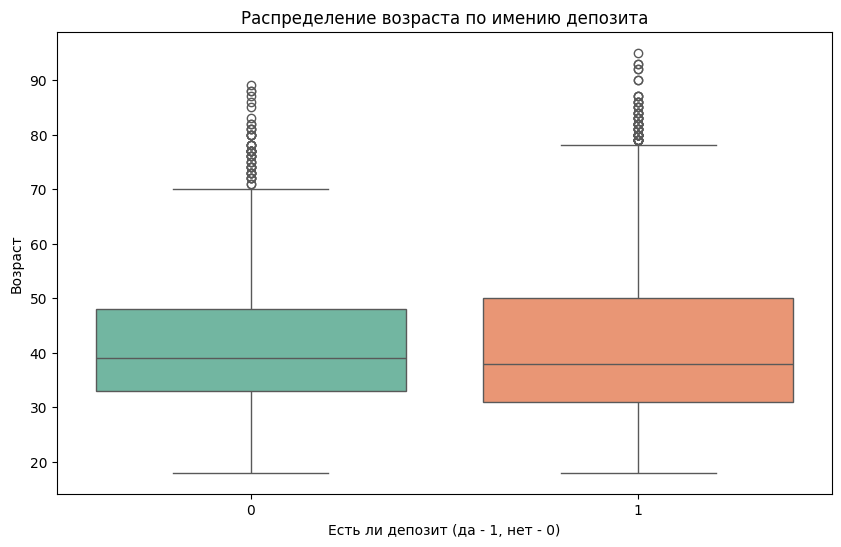

In [3]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='deposit', y='age', data=df, palette='Set2', legend=False, hue='deposit')
plt.title('Распределение возраста по имению депозита')
plt.xlabel('Есть ли депозит (да - 1, нет - 0)')
plt.ylabel('Возраст')

plt.show()

# Подготовка признаков для обучения

In [4]:
y = df['deposit']

X = pd.get_dummies(df.drop('deposit', axis=1), columns=['housing', 'marital', 'job', 'education', 'default', 'loan', 'month'], drop_first=True)

print('Данные после обработки категоральных признаков:\n')
X.head(3)

Данные после обработки категоральных признаков:



,age,balance,day,duration,campaign,pdays,previous,housing_yes,marital_married,marital_single,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,59,2343,5,1042,1,-1,0,True,True,False,...,False,False,False,False,False,False,True,False,False,False
1,56,45,5,1467,1,-1,0,False,True,False,...,False,False,False,False,False,False,True,False,False,False
2,41,1270,5,1389,1,-1,0,True,True,False,...,False,False,False,False,False,False,True,False,False,False


# Масштабирование и разбиение данных для обучения

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train.head(3)

,age,balance,day,duration,campaign,pdays,previous,housing_yes,marital_married,marital_single,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
8644,0.412051,-0.321431,1.817208,-0.343988,0.178481,-0.484037,-0.355931,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2632,0.412051,0.359538,-1.504820,-0.317972,-0.540031,0.386954,3.075684,False,True,False,...,False,False,False,False,False,False,False,False,False,True
3056,-1.356310,-0.451508,-0.555669,-0.485632,-0.540031,0.359449,0.073021,False,False,True,...,False,False,True,False,False,False,False,False,False,False


# Обучение модели и оценка взятия депозита

In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100
print(f'Общая точность модели (Accuracy): {accuracy:.2f}%\n')

Общая точность модели (Accuracy): 83.61%

